# Pretraining on unlabelled data

In [7]:
import torch.nn as nn
import torch
from ch4_gpt_architecture import GPTModel
from ch3_attention_mechanism import MultiHeadAttention

In [31]:
#### defining the device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')

In [32]:
device

device(type='mps')

In [33]:
# ch4_gpt_architecture??

## Defining configuration and basic tests

In [34]:
GPT_CONFIG_124M = {'vocab_size': 50257,
                 'context_length': 256, #changed for experimentation
                 'emb_dim': 768,
                 'n_heads': 12,
                 'n_layers': 12,
                 'drop_rate': 0.1,
                 'qkv_bias': False}

In [35]:
torch.manual_seed(123)

In [36]:
model = GPTModel(GPT_CONFIG_124M)

In [37]:
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

## module to convert text to token ids

In [38]:
import tiktoken
from ch4_gpt_architecture import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
    #adding batch dimension
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    #removes batch dimension
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = 'Every effort moves you'
tokenizer = tiktoken.get_encoding('gpt2')

token_ids = generate_text_simple(model = model, idx = text_to_token(start_context, tokenizer),
                                max_new_tokens = 10,
                                context_size = GPT_CONFIG_124M['context_length'])
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you 960esame WindsorFE Keith awaitedSer seriously Estimated stren


## Creating function to computer training and validation loss

In [39]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches = None):
    total_loss = 0
    if len(data_loader) == 0:
        return float('nan')
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss+=loss.item()
        else:
            break
    return total_loss / num_batches

In [40]:
#testing the calc_loss_loader
from ch2_data_loader import create_dataloader_v1
torch.manual_seed(123)

file_path = './raw_data/the-verdict.txt'
with open(file_path, 'r', encoding = 'utf-8') as file:
    text_data = file.read()

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(f"total_characters: {total_characters}")
print(f"total tokens: {total_tokens}")

train_ratio = 0.9
train_data = text_data[:int(len(text_data) * train_ratio)]
val_data = text_data[int(len(text_data) * train_ratio):]




total_characters: 20479
total tokens: 5145


In [41]:
train_loader = create_dataloader_v1(train_data, batch_size = 2, max_length = GPT_CONFIG_124M['context_length'],
                                   stride = GPT_CONFIG_124M['context_length'],
                                   drop_last = True,
                                   shuffle = True,
                                   num_workers = 0)
val_loader = create_dataloader_v1(val_data, batch_size = 2, max_length = GPT_CONFIG_124M['context_length'],
                                   stride = GPT_CONFIG_124M['context_length'],
                                   drop_last = True,
                                   shuffle = True,
                                   num_workers = 0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print(f"Training loss: {train_loss}")
print(f"Validation loss: {val_loss}")

Training loss: 10.997505823771158
Validation loss: 10.98891830444336


## Listing 5.3: Function for pre-training LLMs

In [42]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq,
                      eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch {epoch+1}, Step {global_step}, Tokens Seen: {tokens_seen}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen

In [43]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches = eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches = eval_iter)
        model.train()
        return train_loss, val_loss

In [44]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model, idx = encoded, max_new_tokens = 50, context_size = context_size)
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

### Experiment window

In [45]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
     model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen= train_model_simple(
model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
start_context="Every effort moves you", tokenizer=tokenizer )

Epoch 1, Step 0, Tokens Seen: 512, Train Loss: 9.8354, Val Loss: 9.9922
Epoch 1, Step 5, Tokens Seen: 3072, Train Loss: 8.0883, Val Loss: 8.3726
Every effort moves you,.                                                
Epoch 2, Step 10, Tokens Seen: 5632, Train Loss: 6.7590, Val Loss: 7.0531
Epoch 2, Step 15, Tokens Seen: 8192, Train Loss: 6.1002, Val Loss: 6.5927
Every effort moves you, the,, the,, the, the, the.   ", the,,, the,, the,,, the,, the,,, the, the,, the, the, the,,, the
Epoch 3, Step 20, Tokens Seen: 10752, Train Loss: 5.7622, Val Loss: 6.5120
Epoch 3, Step 25, Tokens Seen: 13312, Train Loss: 5.2193, Val Loss: 6.3514
Every effort moves you.                           "I"I theHe--I theHe the--I the picture and I had"I was I
Epoch 4, Step 30, Tokens Seen: 15872, Train Loss: 4.8224, Val Loss: 6.2788
Epoch 4, Step 35, Tokens Seen: 18432, Train Loss: 4.2224, Val Loss: 6.3279
Every effort moves you, and, and he was a of the picture--I had been. "I--and I--and it's the picture to t

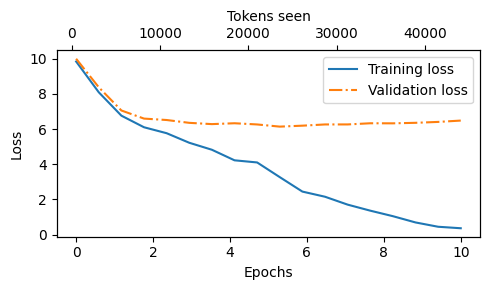

In [50]:
# graph for quick check
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3)) 
    ax1.plot(epochs_seen, train_losses, label="Training loss") 
    ax1.plot( 
    epochs_seen, val_losses, linestyle="-.", label="Validation loss" )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right") 
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) 
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses)) 
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## utilizing decoding strategies to control randomness - >temperature and top-k sampling

### modiying the text generation function

In [51]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
 
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [52]:
torch.manual_seed(123)
token_ids = generate(
model=model,
idx=text_to_token_ids("Every effort moves you", tokenizer), max_new_tokens=15, context_size=GPT_CONFIG_124M["context_length"],
top_k=25,
temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves youlit terrace. And how it as it were, one handsome, in


## Loading and saving model weights in pytorch

In [54]:
#saving weights
torch.save(model.state_dict(), "model_v1.pth")

In [55]:
#loading weights via state dict
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model_v1.pth", map_location = device))
#model.eval() swtiches the model to evaluation model -- disabling the dropout layers
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [57]:
#If we plan on loading the weights and then train the model for some more steps, we'll need to save the optimized state as well (like AdamW in this case)
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer_v1.pth"
)


In [59]:
#loading the model along with weights and optimizer state
checkpoint = torch.load("model_and_optimizer_v1.pth", map_location = device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-04, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

## Loading pre-trained weights from OpenAIm

In [68]:
#open ai saved weights via tensorflow -> so need to install tensorflow and tqdm
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x13913a850>)

In [70]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir = 'gpt2')

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 82.3kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:02<00:00, 424kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 39.6kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [08:05<00:00, 1.03MiB/s]   
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 4.93MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 330kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 327kiB/s]  


In [71]:
#Inspecting contents of settings and parameters
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [72]:
#checking weights and shape of token embeddings layer
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [73]:
#we'll need to transfer the weights of GPT-2 from settings and params dictionaries to out GPTModel instance. Let's create a dictionary to list the differences b/w different GPT model sizes in figure 5.17
model_configs = {
"gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12}, "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16}, "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20}, "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [74]:
#we are interested in this smallest model for now
model_name = "gpt2-small (124M)"

#copy of the old config
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

In [75]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [76]:
#rightnow the GPTModel instance is assigned with random weights for pretraining. The final step is to override these random weights with what we loaded in the params dictionary form openAI's gpt
#Creating an assign function to check the shape and dimension for the weights assignment
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, " "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))


## Loading open AI weights into out model

In [77]:
#this is a big chunk of code
import numpy as np
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe']) 
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1) 
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        q_b, k_b, v_b = np.split( (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
        gpt.trf_blocks[b].att.out_proj.weight = assign( gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
    
        gpt.trf_blocks[b].att.out_proj.bias = assign( gpt.trf_blocks[b].att.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.trf_blocks[b].ff.layers[0].weight = assign( gpt.trf_blocks[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign( gpt.trf_blocks[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])
    
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"]) 
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"]) 
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [78]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [79]:
#generating text using the model to test if loaded correctly
torch.manual_seed(123)
token_ids = generate(
model=gpt,
idx=text_to_token_ids("Every effort moves you", tokenizer).to(device), max_new_tokens=25,
context_size=NEW_CONFIG["context_length"],
top_k=50,
temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?


